## Homework 03: due 2024/04/25 23:59(100%)

### - Tutorial : 
___1. scipy.signal.convolve2d:___ https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html

___2. OpenCV2 Convolution:___ https://blog.csdn.net/hysterisis/article/details/113097507

___3. cv2.filter2D:___ https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04 
                   
### - After you go through the tutorials, you should be able to work on this assignment.

### - Please directly answer the following questions and work on this jupyter notebook.

### - Make sure the code can be run and show the result and figures properly.

### - Please briefly write down your observation with markdown in this notebook.

In [1]:
import cv2
import os
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

#### 1. Please use the defined input matrix and the kernel below, and use the ___scipy.signal.convolve2d___ and ___cv2.filter2D___ to implement the convolution operation. The result output after convolution is given for your reference. (With half zero padding to make the shape fixed) (50%)

* half zero padding means padding zero on on all four edges (top, bottom, left, right): to make the output equal to input size  

### Example with a 5×5 Kernel
Let’s say:

Kernel size: k = 5

Then half of k is:
  $$
  \text{floor}(5/2) = 2
  $$

So we add:

2 rows on top and bottom,

2 columns on the left and right.

### This is called “same” padding because it ensures:
$$
Output size=Input size
$$
It’s often referred to as “half padding” because the amount of padding added on each side is half the size of the kernel.

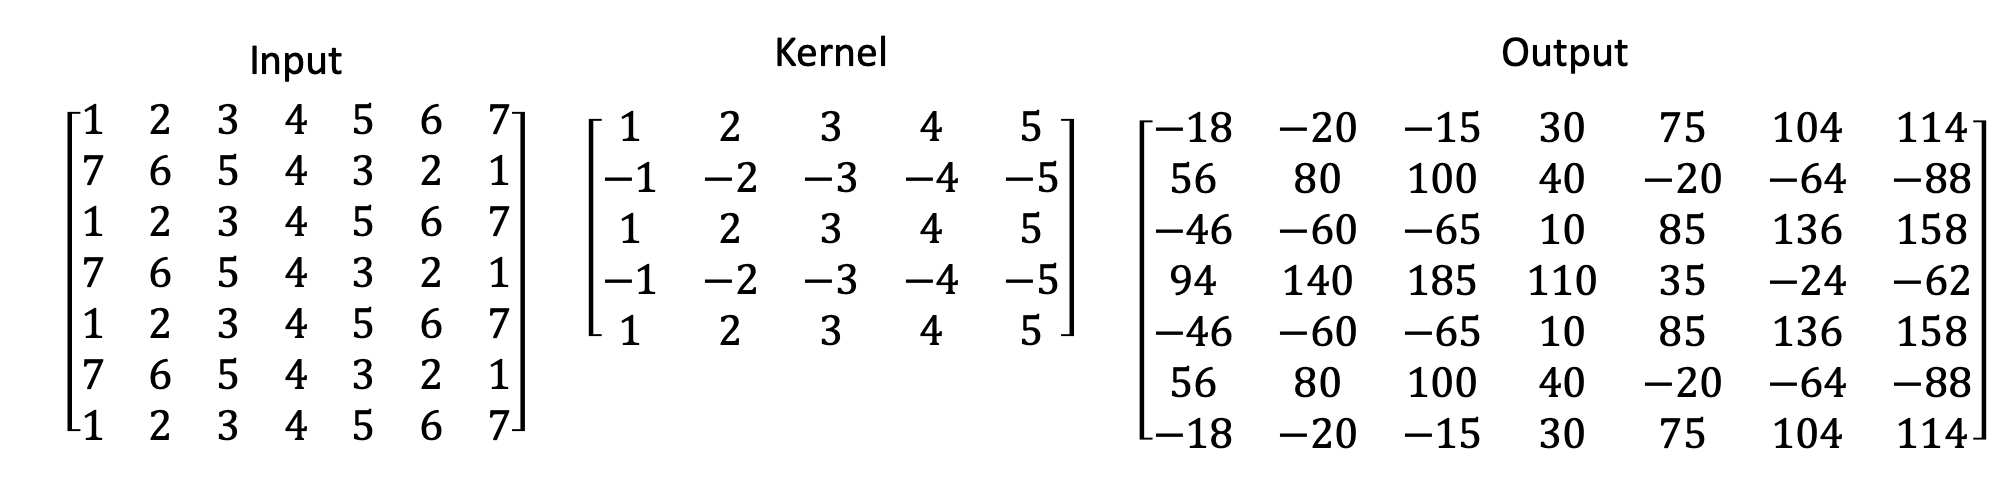

In [2]:
input = np.array([[1, 2, 3, 4, 5, 6, 7],
                  [7, 6, 5, 4, 3, 2, 1],
                  [1, 2, 3, 4, 5, 6, 7],
                  [7, 6, 5, 4, 3, 2, 1],
                  [1, 2, 3, 4, 5, 6, 7],
                  [7, 6, 5, 4, 3, 2, 1],
                  [1, 2, 3, 4, 5, 6, 7],], dtype=np.float32)

kernel = np.array([[ 1,  2,  3,  4,  5],
                   [-1, -2, -3, -4, -5],
                   [ 1,  2,  3,  4,  5],
                   [-1, -2, -3, -4, -5],
                   [ 1,  2,  3,  4,  5],], dtype=np.float32)

output1 = signal.convolve2d(input, kernel, mode='same')
output2 = cv2.filter2D(src=input, ddepth=-1, kernel=cv2.flip(kernel, -1), borderType=cv2.BORDER_CONSTANT)

print("Scipy output:\n", output1)
print("\nOpenCV output:\n", output2)

Scipy output:
 [[-18. -20. -15.  30.  75. 104. 114.]
 [ 56.  80. 100.  40. -20. -64. -88.]
 [-46. -60. -65.  10.  85. 136. 158.]
 [ 94. 140. 185. 110.  35. -24. -62.]
 [-46. -60. -65.  10.  85. 136. 158.]
 [ 56.  80. 100.  40. -20. -64. -88.]
 [-18. -20. -15.  30.  75. 104. 114.]]

OpenCV output:
 [[-18. -20. -15.  30.  75. 104. 114.]
 [ 56.  80. 100.  40. -20. -64. -88.]
 [-46. -60. -65.  10.  85. 136. 158.]
 [ 94. 140. 185. 110.  35. -24. -62.]
 [-46. -60. -65.  10.  85. 136. 158.]
 [ 56.  80. 100.  40. -20. -64. -88.]
 [-18. -20. -15.  30.  75. 104. 114.]]


### 1. `scipy.signal.convolve2d()`

#### 📌 Purpose:

Performs **2D convolution** between two 2D arrays (e.g., an image and a filter). Automatically handles **kernel flipping**, matching the mathematical definition of convolution.

#### Key Parameters:

| Parameter   | Description                                                              |
| ----------- | ------------------------------------------------------------------------ |
| `input`     | The 2D input array (e.g., image or data matrix)                          |
| `kernel`    | The 2D filter (will be **automatically flipped** internally)             |
| `mode`      | Controls the output size: `'full'`, `'same'`, `'valid'`                  |
| `boundary`  | How to pad the edges: `'fill'`, `'wrap'`, `'symm'`                       |
| `fillvalue` | The value to pad with (used only when `boundary='fill'`, default is `0`) |

#### Common Modes:

| Mode      | Output Size                  | Padding      |
| --------- | ---------------------------- | ------------ |
| `'valid'` | No padding → smaller output  | None         |
| `'same'`  | Output same size as input    | Half padding |
| `'full'`  | Includes full kernel sliding | Full padding |

### 🔷 2. `cv2.filter2D()`

#### 📌 Purpose:

Applies a 2D **correlation** or **convolution** operation (from OpenCV). You must **manually flip** the kernel for convolution.

#### ✅ Key Parameters:

| Parameter    | Description                                                                    |
| ------------ | ------------------------------------------------------------------------------ |
| `src`        | The 2D input array (e.g., image or data matrix)                                |
| `ddepth`     | Depth of the output image (use `-1` to keep the same as input)                 |
| `kernel`     | The 2D filter; **must be flipped** manually using `cv2.flip()` for convolution |
| `borderType` | Controls edge behavior (padding): `BORDER_CONSTANT`, `BORDER_REFLECT`, etc.    |

#### 📦 Common `borderType` Values:

| Type                  | Description                               |
| --------------------- | ----------------------------------------- |
| `cv2.BORDER_CONSTANT` | Pads with 0s (like `'fill', fillvalue=0`) |
| `cv2.BORDER_REFLECT`  | Mirrors the border (like `'symm'`)        |
| `cv2.BORDER_WRAP`     | Wraps around edges (like `'wrap'`)        |

<br>
---


### 🔍 Key Differences

| Feature                        | `scipy.signal.convolve2d`                 | `cv2.filter2D`                                |
| ------------------------------ | ----------------------------------------- | --------------------------------------------- |
| Kernel flipping                | **Automatic**                             | Must do manually using `cv2.flip(kernel, -1)` |
| Padding                        | Controlled via `boundary` and `fillvalue` | Controlled via `borderType`                   |
| Output size control            | `'same'`, `'valid'`, `'full'`             | Output is **always same size**                |
| Output data type control       | Automatic                                 | Use `ddepth` parameter                        |
| Native support for correlation | No (always convolution)                   | Yes (by default, does correlation)            |


<br>
---

### how to choose the right dtype
| If your input...            | Then use...        | Reason                                    |
| --------------------------- | ------------------ | ----------------------------------------- |
| Is an image (0–255 values)  | `np.uint8` or `-1` | Compact and display-compatible            |
| Needs decimal precision     | `np.float32`       | Filters like blur/convolution work better |
| Requires high-accuracy math | `np.float64`       | For scientific simulations                |



### ✅ When to Use Which?

| Situation                                | Recommended Function               |
| ---------------------------------------- | ---------------------------------- |
| Mathematical convolution                 | `scipy.signal.convolve2d`          |
| Real-time image processing               | `cv2.filter2D` (faster, optimized) |
| Need custom padding (mirror, wrap, etc.) | Both (support with options)        |
| Precision control on data type           | `cv2.filter2D` with `ddepth`       |



#### 2. Please do the covolution operation on your own image or on the given __test.jpg__ with all the kernels below. (50%)

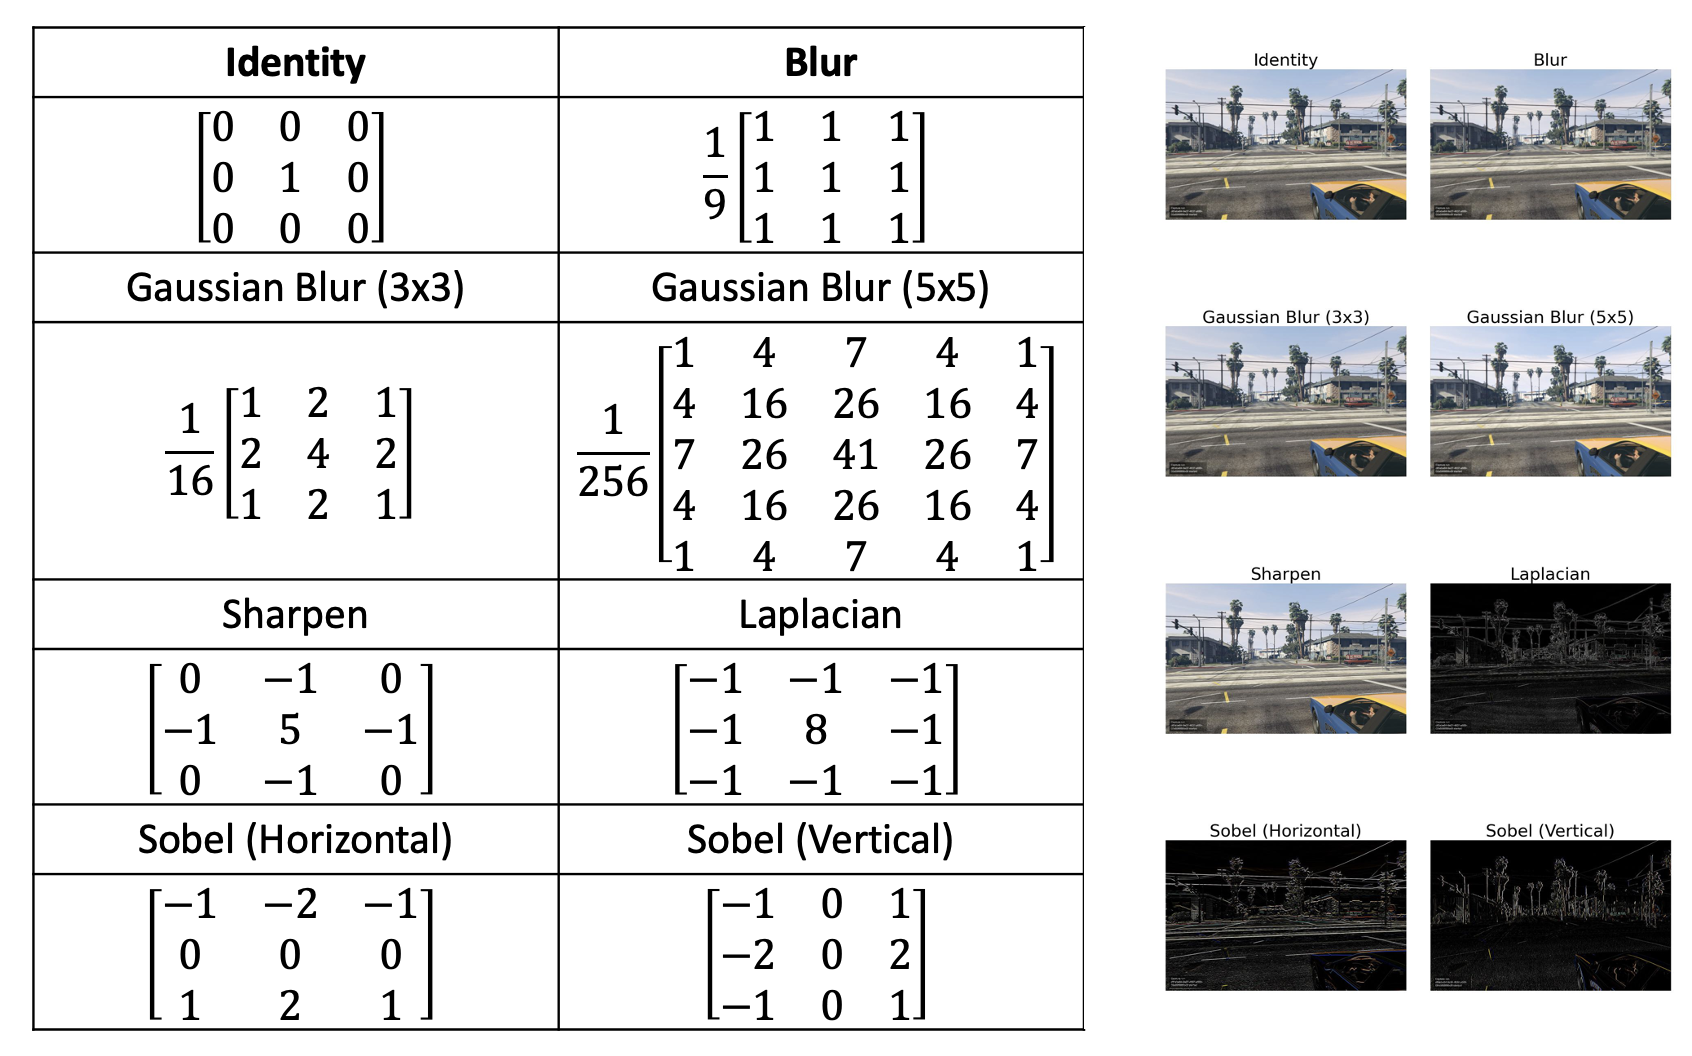

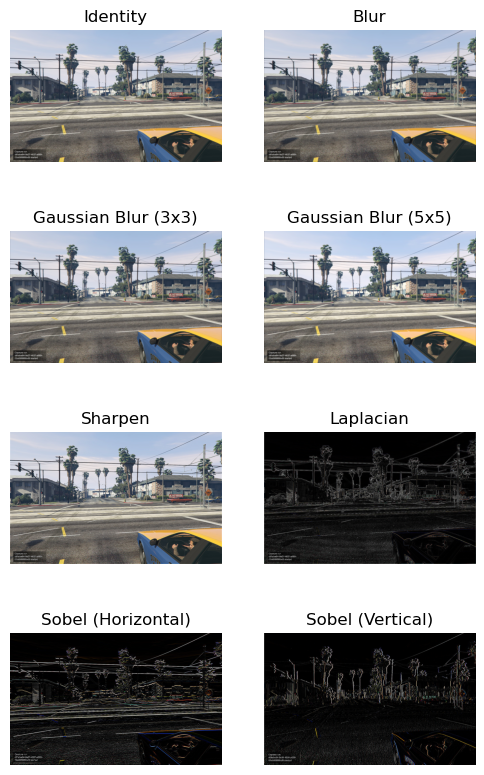

In [3]:
img = cv2.imread("test.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

kernel_identity = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]])
kernel_blur = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]]) / 9
kernel_gaussian_blur_3 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]]) / 16
kernel_gaussian_blur_5 = np.array([
    [1,  4,  7,  4, 1],
    [4, 16, 26, 16, 4],
    [7, 26, 41, 26, 7],
    [4, 16, 26, 16, 4],
    [1,  4,  7,  4,  1]]) / 256
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]])
kernel_laplacian = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]])
kernel_sobel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]])
kernel_sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]])
kernel_all = [kernel_identity, kernel_blur, kernel_gaussian_blur_3, kernel_gaussian_blur_5, kernel_sharpen, kernel_laplacian, kernel_sobel_horizontal, kernel_sobel_vertical]
kernel_name = ["Identity", "Blur", "Gaussian Blur (3x3)", "Gaussian Blur (5x5)", "Sharpen", "Laplacian", "Sobel (Horizontal)", "Sobel (Vertical)"]

fig, ax = plt.subplots(4, 2, figsize=(6, 10))
for i, x in enumerate(kernel_all):
    output = cv2.filter2D(src=img, ddepth=-1, kernel=x, borderType=cv2.BORDER_CONSTANT)
    ax[int(i//2), int(i%2)].imshow(output)
    ax[int(i//2), int(i%2)].set_title(kernel_name[i])
    ax[int(i//2), int(i%2)].axis("off")
plt.show()

### ✅ Summary

| Line                                   | Purpose                  | Result Format                           |
| -------------------------------------- | ------------------------ | --------------------------------------- |
| `cv2.imread`                           | Loads the image (as BGR) | NumPy array, shape `(h, w, 3)`, `uint8` |
| `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` | Converts BGR → RGB       | For display with Matplotlib or PIL      |


After applying various convolution kernels to the image, the following observations were made:

1. **Identity**: The image remains unchanged. This kernel acts as a control to compare the effects of other filters.

2. **Blur**: The image appears softer and less detailed. This is a basic averaging filter that reduces sharpness by smoothing pixel intensities evenly.

3. **Gaussian Blur (3x3)**: Similar to the basic blur, but more natural and visually pleasing due to the Gaussian weighting — pixels closer to the center contribute more. Edges are gently smoothed.

4. **Gaussian Blur (5x5)**: This stronger blur smooths out even more detail, making the image appear significantly softer than the 3x3 version. Useful for noise reduction and pre-processing.

5. **Sharpen**: The image becomes more crisp and detailed, especially around edges. Fine features stand out more, making it ideal for enhancing image clarity.

6. **Laplacian**: Strong edge detection effect in all directions. The result is a high-contrast image where boundaries and transitions in intensity are clearly emphasized. Often used in edge detection.

7. **Sobel (Horizontal)**: Highlights **horizontal intensity changes** (i.e., detects **vertical edges**). Vertical lines and borders stand out clearly.

8. **Sobel (Vertical)**: Highlights **vertical intensity changes** (i.e., detects **horizontal edges**). Horizontal lines such as textures or object tops/bottoms are emphasized.

